In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/kc_house_data.csv')

In [ ]:
print(df.head())
print(df.tail())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     lo

In [ ]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


{'whiskers': [<matplotlib.lines.Line2D at 0x77fcaa21c470>,
 'caps': [<matplotlib.lines.Line2D at 0x77fcaa21eb70>,
 'boxes': [<matplotlib.lines.Line2D at 0x77fcaa21f5c0>,
 'medians': [<matplotlib.lines.Line2D at 0x77fcaa0a44a0>,
 'fliers': [<matplotlib.lines.Line2D at 0x77fcaa0a4680>,
 'means': []}

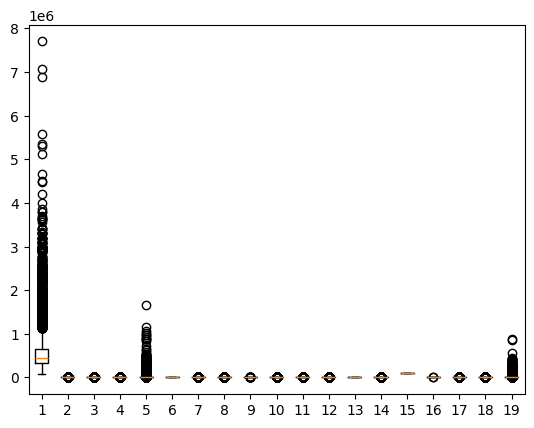

In [ ]:
d = df.drop(['date','id'],axis =1)
from scipy.stats import zscore
z = zscore(d)
df[np.abs(z)>3]

plt.boxplot(d)

In [ ]:
from scipy.stats.mstats import winsorize
df['sqft_lot'] = winsorize(df['sqft_lot'],limits =[0,0.1])
df['sqft_living'] = winsorize(df['sqft_living'],limits=[0,0.1])
df['price'] = winsorize(df['price'],limits =[0,0.1])

In [ ]:
x = df[['sqft_living']]
y = df[['price']]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [ ]:
model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
print("Error = ",mean_squared_error(y_pred,y_test))
print("Error = ",r2_score(y_pred,y_test))

Error =  24748285136.028584
Error =  -0.19869895508481905
